<a href="https://colab.research.google.com/github/marcelalozano27-ship-it/Predicting-CA-Poverty--ML-Project/blob/main/MLFinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Risk of Poverty in CA

Aziza, Fong, Marcela

###  Primary Research Question
Which individuals in California are most vulnerable to poverty based on their education level, employment conditions, demographic characteristics, and access to health insurance?

#### Supporting Sub Questions
1. Education and Poverty Risk: How does education level affect the likelihood of experiencing poverty in California?
2. Employment Conditions and Poverty Risk: Which employment patterns are most associated with poverty risk?
3. Demographic Inequality and Poverty Risk: How do age, marital status, race, and nativity relate to poverty vulnerability?

### Why this topic?

Poverty remains a critical social and economic issue in California, affecting millions of individuals and contributing to inequality in health, education, and economic opportunity. Identifying populations that are most vulnerable to poverty is essential for policymakers, nonprofits, and government agencies to design targeted interventions and allocate resources effectively.

This project leverages machine learning to predict poverty risk based on key factors such as education, employment conditions, demographic characteristics, and access to health insurance. These variables were chosen because they represent structural determinants of economic stability and are commonly used in policy analysis.

In addition to prediction, the project aims to identify the most influential factors driving poverty risk. This allows for actionable insights, helping decision-makers prioritize areas such as education access, employment quality, and healthcare coverage to reduce poverty at scale.

In [ ]:
#install duckdb
#!pip -q install duckdb

SyntaxError: invalid syntax (2863189125.py, line 1)

In [ ]:
#download and unzip
!wget -nc https://www2.census.gov/programs-surveys/acs/data/pums/2024/5-Year/csv_pca.zip
!unzip -o csv_pca.zip

--2026-04-27 04:21:01--  https://www2.census.gov/programs-surveys/acs/data/pums/2024/5-Year/csv_pca.zip
Resolving www2.census.gov (www2.census.gov)... 172.65.90.25, 172.65.90.26, 172.65.90.24, ...
Connecting to www2.census.gov (www2.census.gov)|172.65.90.25|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 268363882 (256M) [application/zip]
Saving to: ‘csv_pca.zip’

csv_pca.zip         100%[===================>] 255.93M   116MB/s    in 2.2s    

2026-04-27 04:21:04 (116 MB/s) - ‘csv_pca.zip’ saved [268363882/268363882]

Archive:  csv_pca.zip
  inflating: psam_p06.csv            
  inflating: ACS2020_2024_PUMS_README.pdf  


In [ ]:
import duckdb
import os
from google.colab import files
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
 cols = pd.read_csv("psam_p06.csv", nrows=0).columns.tolist()
 print(f"Total columns: {len(cols)}")
print(cols)

Total columns: 285
['RT', 'SERIALNO', 'DIVISION', 'SPORDER', 'PUMA', 'REGION', 'STATE', 'ADJINC', 'PWGTP', 'AGEP', 'CIT', 'CITWP', 'COW', 'DDRS', 'DEAR', 'DEYE', 'DOUT', 'DPHY', 'DRAT', 'DRATX', 'DREM', 'ENG', 'FER', 'GCL', 'GCM', 'GCR', 'HINS1', 'HINS2', 'HINS3', 'HINS4', 'HINS5', 'HINS6', 'HINS7', 'INTP', 'JWMNP', 'JWRIP', 'JWTRNS', 'LANX', 'MAR', 'MARHD', 'MARHM', 'MARHT', 'MARHW', 'MARHYP', 'MIG', 'MIL', 'MLPA', 'MLPB', 'MLPCD', 'MLPE', 'MLPFG', 'MLPHJ', 'MLPIK', 'NWAB', 'NWAV', 'NWLA', 'NWLK', 'NWRE', 'OIP', 'PAP', 'RELSHIPP', 'RETP', 'SCH', 'SCHG', 'SCHL', 'SEMP', 'SEX', 'SSIP', 'SSP', 'WAGP', 'WKHP', 'WKL', 'WKWN', 'WRK', 'YOEP', 'ANC', 'ANC1P', 'ANC2P', 'DECADE', 'DIS', 'DRIVESP', 'ESP', 'ESR', 'FOD1P', 'FOD2P', 'HICOV', 'HISP', 'INDP', 'JWAP', 'JWDP', 'LANP', 'MIGPUMA', 'MIGSP', 'MSP', 'NAICSP', 'NATIVITY', 'NOP', 'OC', 'OCCP', 'PAOC', 'PERNP', 'PINCP', 'POBP', 'POVPIP', 'POWPUMA', 'POWSP', 'PRIVCOV', 'PUBCOV', 'QTRBIR', 'RAC1P', 'RAC2P19', 'RAC2P24', 'RAC3P', 'RACAIAN', 'RACA

In [ ]:
import duckdb

con = duckdb.connect()

con.execute("""
COPY (
    SELECT
        RELSHIPP,
        SCHL,
        SCH,
        SCHG,
        ESR,
        WKHP,
        WAGP,
        COW,
        INDP,
        OCCP,
        AGEP,
        SEX,
        RAC1P,
        HISP,
        MAR,
        NATIVITY,
        CIT,
        ENG,
        LANX,
        DRIVESP,
        JWMNP,
        JWTRNS,
        HICOV,
        PRIVCOV,
        PUBCOV,
        DIS,
        DEAR,
        DEYE,
        DPHY,
        FER,
        PINCP,
        SEMP,
        SSIP,
        SSP,
        CASE
            WHEN POVPIP < 100 THEN 1
            ELSE 0
        END AS poverty_status
    FROM read_csv_auto('psam_p06.csv')
    WHERE POVPIP IS NOT NULL
    USING SAMPLE 25000 ROWS
)
TO 'ca_poverty_subset_final.csv' (HEADER, DELIMITER ',');
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
size_mb = os.path.getsize("ca_poverty_subset_final.csv") / (1024 * 1024)
print(f"{size_mb:.2f} MB")

1.73 MB


In [ ]:
files.download("ca_poverty_subset_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Connecting to our subset of the data from Github

In [ ]:
url = "https://raw.githubusercontent.com/marcelalozano27-ship-it/Predicting-CA-Poverty--ML-Project/refs/heads/main/ca_poverty_subset.csv"

df = pd.read_csv(url)

df.head()

,SCHL,ESR,WKHP,WAGP,COW,INDP,OCCP,AGEP,SEX,RAC1P,...,HINS4,HINS5,HINS6,HINS7,DIS,CIT,ENG,LANX,FER,poverty_status
0,21.0,1.0,40.0,8000.0,1.0,7380.0,1021.0,29,1,1,...,2,2,2,2,2,1,NaN,2.0,NaN,0
1,24.0,1.0,60.0,250000.0,1.0,6671.0,1021.0,33,1,1,...,2,2,2,2,2,1,NaN,2.0,NaN,0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,9,...,1,2,2,2,2,1,NaN,NaN,NaN,0
3,22.0,6.0,NaN,0.0,NaN,NaN,NaN,47,2,9,...,2,2,2,2,2,1,NaN,2.0,2.0,1
4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,4,2,1,...,1,2,2,2,2,1,NaN,NaN,NaN,0


In [ ]:
df.shape

(23266, 27)

In [ ]:
df.columns

Index(['SCHL', 'ESR', 'WKHP', 'WAGP', 'COW', 'INDP', 'OCCP', 'AGEP', 'SEX',
       'RAC1P', 'MAR', 'NATIVITY', 'DRIVESP', 'HICOV', 'HINS1', 'HINS2',
       'HINS3', 'HINS4', 'HINS5', 'HINS6', 'HINS7', 'DIS', 'CIT', 'ENG',
       'LANX', 'FER', 'poverty_status'],
      dtype='object')

### Preprocessing and Visualization

In [ ]:
df.describe()

,SCHL,ESR,WKHP,WAGP,COW,INDP,OCCP,AGEP,SEX,RAC1P,...,HINS4,HINS5,HINS6,HINS7,DIS,CIT,ENG,LANX,FER,poverty_status
count,22672.000000,19465.000000,12269.000000,19745.000000,14064.000000,14064.000000,14064.000000,23266.000000,23266.000000,23266.000000,...,23266.000000,23266.000000,23266.000000,23266.000000,23266.000000,23266.000000,9386.000000,22233.000000,5307.000000,23266.000000
mean,16.257454,3.050398,37.269378,40881.594834,2.234499,6528.101536,3922.620165,41.839465,1.507350,4.394825,...,1.754835,1.978509,1.981905,1.995659,1.869982,1.958265,1.652461,1.577835,1.951573,0.123012
std,5.993837,2.390938,13.062117,76039.137072,1.997805,2553.515618,2678.306590,23.107018,0.499957,3.369419,...,0.430194,0.145016,0.133298,0.065745,0.336331,1.541300,0.923749,0.493916,0.214686,0.328458
min,1.000000,1.000000,1.000000,0.000000,1.000000,170.000000,10.000000,0.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,1.000000,32.000000,0.000000,1.000000,5171.000000,1760.000000,23.000000,1.000000,1.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,2.000000,0.000000
50%,18.000000,1.000000,40.000000,10000.000000,1.000000,7390.000000,4000.000000,42.000000,2.000000,5.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,0.000000
75%,21.000000,6.000000,40.000000,55000.000000,3.000000,8191.000000,5400.000000,60.000000,2.000000,8.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,2.000000,2.000000,2.000000,0.000000
max,24.000000,6.000000,99.000000,687000.000000,9.000000,9920.000000,9920.000000,94.000000,2.000000,9.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,5.000000,4.000000,2.000000,2.000000,1.000000


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
FER,17959
DRIVESP,15237
ENG,13880
WKHP,10997
OCCP,9202
INDP,9202
COW,9202
ESR,3801
WAGP,3521
LANX,1033



## Dataset Variables and Definitions:

This dataset uses selected variables from the American Community Survey (ACS) Public Use Microdata Sample (PUMS) to analyze poverty vulnerability among individuals in California. The target variable is **poverty_status**, which indicates whether a respondent falls below the federal poverty threshold.

---

### Target Variable

**poverty_status**  
Binary indicator of poverty status  
- 1 = Below poverty line  
- 0 = Above poverty line  
Derived from the income-to-poverty ratio (POVPIP)

---

### Education Variables

**SCHL**  
Highest level of educational attainment completed by the respondent. Education level is a strong predictor of long-term economic opportunity and poverty risk.

---

### Employment and Income Variables

**ESR**  
Employment status (employed, unemployed, or not in the labor force)

**WKHP**  
Usual number of hours worked per week

**WAGP**  
Total wage and salary income earned in the past 12 months

**COW**  
Class of worker (private sector, government, self-employed, etc.)

**INDP**  
Industry of employment

**OCCP**  
Occupation category

These variables describe workforce participation and earning potential.

---

### Demographic Variables

**AGEP**  
Age of respondent

**SEX**  
Biological sex of respondent

**RAC1P**  
Race category

**MAR**  
Marital status

**NATIVITY**  
Indicates whether the respondent is U.S.-born or foreign-born

These variables help capture structural differences in poverty exposure across population groups.

---

### Health Insurance Coverage Variables

**HICOV**  
Indicator for whether the respondent has any health insurance coverage

**HINS1**  
Employer-sponsored insurance coverage

**HINS2**  
Directly purchased insurance coverage

**HINS3**  
Medicare coverage

**HINS4**  
Medicaid coverage

**HINS5**  
TRICARE or military health coverage

**HINS6**  
Veterans Affairs (VA) health coverage

**HINS7**  
Indian Health Service coverage

Insurance access reflects financial stability and access to healthcare resources.

---

### Language and Citizenship Variables

**CIT**  
Citizenship status

**ENG**  
English-speaking ability

**LANX**  
Indicator for whether a language other than English is spoken at home

Language proficiency and citizenship status can influence employment opportunities and income outcomes.

---

### Disability and Transportation Variables

**DIS**  
Disability status indicator

**DRIVESP**  
Number of vehicles available in the household

Transportation access and disability status affect workforce participation and economic mobility.

---

### Excluded Variable

**FER**  
Indicator for whether respondent gave birth in the past 12 months.  
This variable was removed due to high missingness and limited relevance to poverty prediction for the full population sample.


In [ ]:
df = df.drop(columns=["FER"])

In [ ]:
employment_cols = ["WKHP", "WAGP", "COW", "INDP", "OCCP", "ESR"]

for col in employment_cols:
    df[col] = df[col].fillna(0)

In [ ]:
df["DRIVESP"] = df["DRIVESP"].fillna(df["DRIVESP"].median())

In [ ]:
df["ENG"] = df["ENG"].fillna(df["ENG"].mode()[0])

In [ ]:
df["SCHL"] = df["SCHL"].fillna(df["SCHL"].median())

In [ ]:
df["LANX"] = df["LANX"].fillna(df["LANX"].mode()[0])

### Missing Value Handling Strategy

Given the large number of missing values for FER (Fertility), this variable was removed from the dataset. Fertility information is only applicable to a subset of respondents and is not directly relevant to predicting poverty status across the full population sample.

For employment-related variables (WKHP, WAGP, COW, INDP, OCCP, ESR), missing values were filled with 0. In the ACS dataset, missing employment information usually suggests an individual is not currently working and not that the status is unkown. Replacing these values with zero preserves observations without introducing bias from row deletion.

For DRIVESP (Number of vehicles in the household) and SCHL (Highest level of educational attainment), missing values were filled using the median. Median imputation was selected because it preserves the distribution of the data while reducing the influence of extreme values.

For the LANX (Language other than English spoken at home) and ENG (English proficiency) variables, missing values were filled using the mode. These variables are categorical indicators, so replacing missing values with the most common category maintains interpretability and consistency across observations.

This imputation strategy allows the dataset to retain a large sample size while ensuring that missing values are handled in a way that reflects the structure of ACS survey data and supports reliable model training.


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
SCHL,0
ESR,0
WKHP,0
WAGP,0
COW,0
INDP,0
OCCP,0
AGEP,0
SEX,0
RAC1P,0


In [ ]:
df["poverty_status"].value_counts(normalize=True)

,proportion
poverty_status,
0,0.876988
1,0.123012


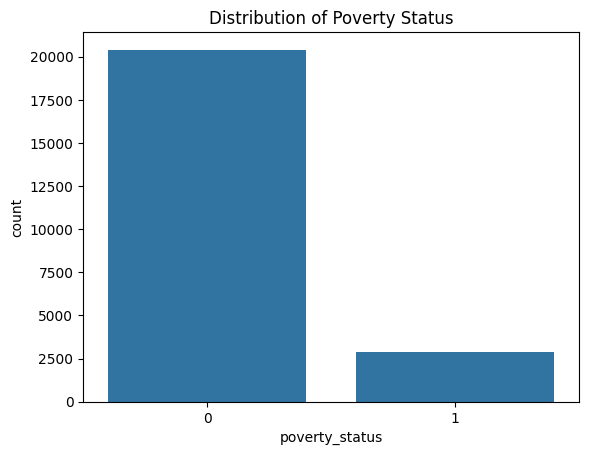

In [ ]:
sns.countplot(x="poverty_status", data=df)
plt.title("Distribution of Poverty Status")
plt.show()

Key Predictors of Poverty Status

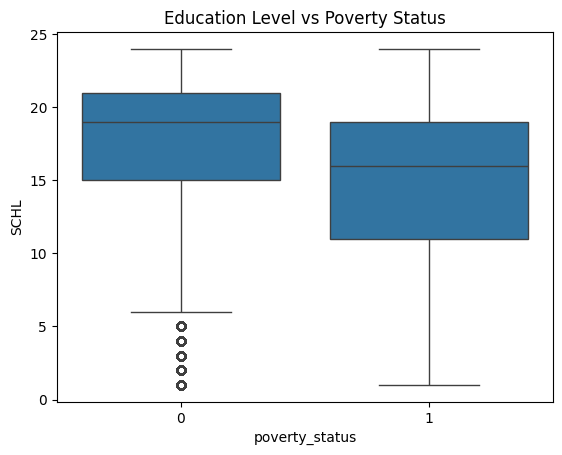

In [ ]:
sns.boxplot(x="poverty_status", y="SCHL", data=df)
plt.title("Education Level vs Poverty Status")
plt.show()

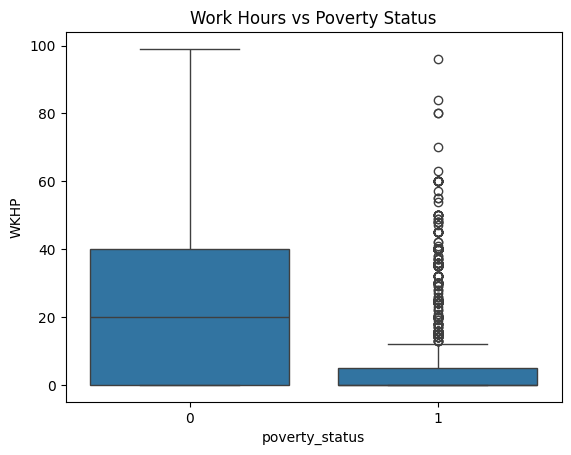

In [ ]:
sns.boxplot(x="poverty_status", y="WKHP", data=df)
plt.title("Work Hours vs Poverty Status")
plt.show()

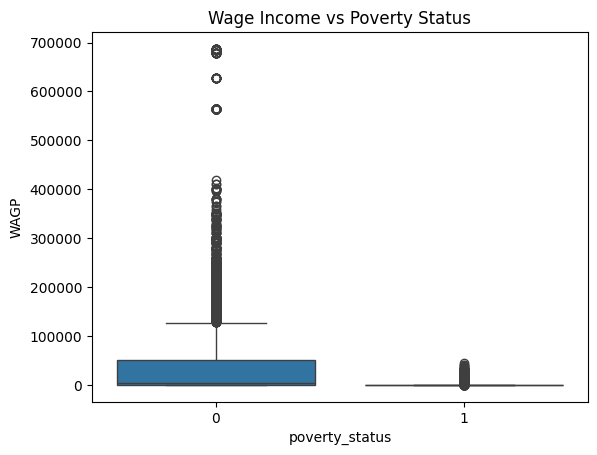

In [ ]:
sns.boxplot(x="poverty_status", y="WAGP", data=df)
plt.title("Wage Income vs Poverty Status")
plt.show()

In [ ]:
df.columns

Index(['SCHL', 'ESR', 'WKHP', 'WAGP', 'COW', 'INDP', 'OCCP', 'AGEP', 'SEX',
       'RAC1P', 'MAR', 'NATIVITY', 'DRIVESP', 'HICOV', 'HINS1', 'HINS2',
       'HINS3', 'HINS4', 'HINS5', 'HINS6', 'HINS7', 'DIS', 'CIT', 'ENG',
       'LANX', 'poverty_status'],
      dtype='object')

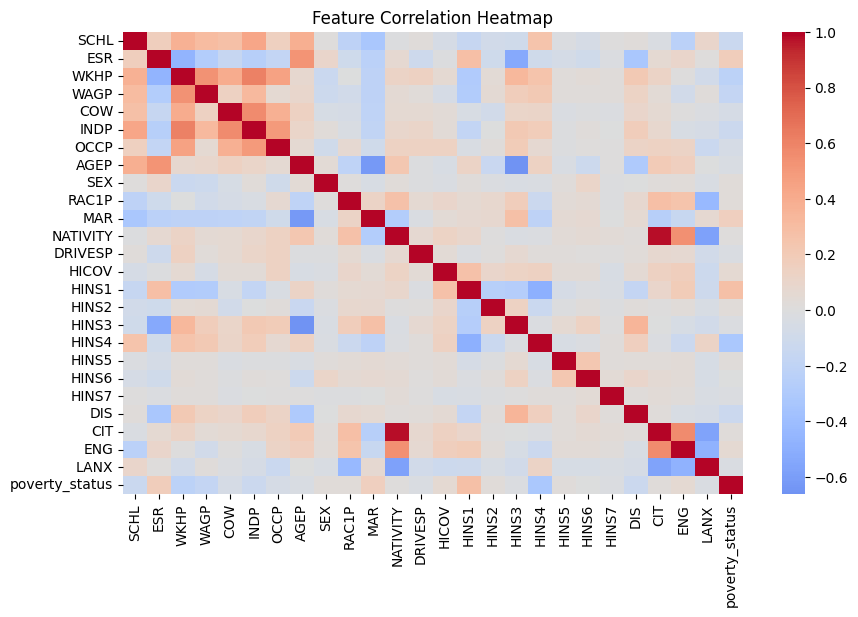

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

#### Feature Correlation Heatmap Interpretation


Several employment related variables have the strongest relationships with poverty status. WAGP (wage income) and WKHP (hours worked per week) display negative correlations with poverty status, indicating that individuals with higher earnings and greater work participation are less likely to fall below the poverty threshold.

Education level (SCHL) also shows a negative relationship with poverty status, suggesting that higher education is associated with reduced poverty vulnerability.

Health insurance indicators provide additional signals about economic stability. Employer sponsored coverage tends to correlate with lower poverty risk, while public insurance indicators like Medicaid show positive relationships with poverty status. This is expected as they are safety-net programs for lower income populations.

Language proficiency and citizenship variables, including ENG, LANX, and CIT, also show correlations with poverty outcomes which suggests that structural barriers related to language access and immigration status may influence economic opportunity.

Correlations among predictor variables remain relatively low overall. This indicates limited multicollinearity and we can safely include all variables in the logistic regression model without distorting coefficient estimates.

In [ ]:
#Separating Predictors and Target Variable
X = df.drop(columns=["poverty_status"])
y = df["poverty_status"]

In [ ]:
# Convert categorical variables to dummy variables
X = pd.get_dummies(X, drop_first=True)

In [ ]:
#Train/Test Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale after split
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (18612, 25)
Testing shape: (4654, 25)


The data was divided into training and testing sets using a traditional 80/20 split. We used a stratified sampling approach to preserve the distribution of poverty status in both the training and testing data.

We also applied feature scaling using StandardScaler. This is primarily for the Logistic Regression which is more sensitive to differences in feature scales.

## Model 1: Logistic Regression (AZIZA)

Which factors increase poverty vulnerability in California?

In [ ]:
# Features (drop target)
X = df.drop(columns=["poverty_status"])

# Target
y = df["poverty_status"]

In [ ]:
#Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
#Scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Train Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
#Evaluate Model
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      6121
           1       0.51      0.18      0.26       859

    accuracy                           0.88      6980
   macro avg       0.70      0.58      0.60      6980
weighted avg       0.85      0.88      0.85      6980

ROC-AUC: 0.8457858678086605
Confusion Matrix:
 [[5977  144]
 [ 708  151]]


In [ ]:
#Feature Importance
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance["Abs"] = abs(importance["Coefficient"])
importance = importance.sort_values(by="Abs", ascending=False)

importance.head(10)

,Feature,Coefficient,Abs
3,WAGP,-5.816770,5.816770
10,MAR,0.589795,0.589795
17,HINS4,-0.490954,0.490954
14,HINS1,0.408429,0.408429
1,ESR,0.303585,0.303585
7,AGEP,0.258585,0.258585
22,CIT,0.250480,0.250480
16,HINS3,0.226521,0.226521
13,HICOV,0.184800,0.184800
2,WKHP,0.179564,0.179564


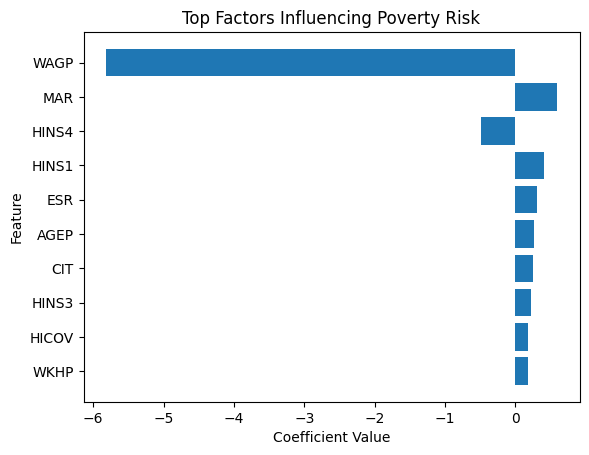

In [ ]:
#Feature Importance Bar Chart
import matplotlib.pyplot as plt

# Top 10 features
top_features = importance.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top Factors Influencing Poverty Risk")
plt.gca().invert_yaxis()
plt.show()

The feature importance chart shows the variables that have the strongest influence on poverty risk. Wage income (WAGP) stands out as the most significant factor, with a strong negative coefficient, indicating that higher income greatly reduces the likelihood of being in poverty. Other factors such as marital status, employment status, and age also contribute to poverty risk, while health insurance-related variables suggest that access to resources plays an important role. Overall, the chart highlights that income, employment, and access to support systems are key drivers of poverty vulnerability.

Logistic Regression Model Analysis:

• Wage Income (WAGP) is the most influential factor, with higher income significantly reducing the likelihood of being in poverty.

• Marital status and employment status both play important roles, with unemployed or single individuals showing higher vulnerability.

• Age contributes to poverty risk, suggesting that certain age groups are more economically vulnerable.
• Health insurance variables (HINS1, HINS3, HINS4, HICOV) indicate that access to healthcare and benefits is strongly associated with economic stability.

• While the model captures key drivers effectively, it struggles to identify all individuals in poverty due to class imbalance, as shown by its low recall for the poverty class.

Overall, the results reinforce that income, employment stability, and access to resources are the primary drivers of poverty vulnerability, even though the model’s predictive ability for detecting all vulnerable individuals remains limited.

## Model 2: Random Forest (MARCELA)

We are using a Random Forest model to identify which are the most important predictors of poverty status. Unlike the logistic regression, the RF Model does not assume a linear relationship and is able to capture more complex relationships between predictors.

The strength of the predictor is based off its contribution to classification accuracy.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
import joblib
import requests
import io

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=42
)

model_url = "https://raw.githubusercontent.com/marcelalozano27-ship-it/Predicting-CA-Poverty--ML-Project/main/random_forest_poverty_model.pkl"

response = requests.get(model_url)
rf_model = joblib.load(io.BytesIO(response.content))

print("Random Forest model loaded from GitHub successfully.")

# Predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest model loaded from GitHub successfully.
Random Forest Accuracy: 0.8360550064460679

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.87      0.90      4082
           1       0.39      0.62      0.48       572

    accuracy                           0.84      4654
   macro avg       0.67      0.74      0.69      4654
weighted avg       0.87      0.84      0.85      4654


Confusion Matrix:

[[3539  543]
 [ 220  352]]


### Random Forest Model Performance

Our model achieved an overall accuracy of 80 percent however given the imbalanced dataset (poverty cases represent the minority class) so recall provides a more meaningful evaluation of the model.

The model correctly identified 73% of individuals below the poverty threshold which is strong performance. The precision however was lower at 35% likely due to the model's emphasis on minimizing missed poverty cases rather than minimizing false positives.

The results emphasize that demographic, employment and insurance related features provide significant predicitive power for identifying poverty risk in California households.

In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
WAGP,0.244909
HINS1,0.126696
HINS4,0.120465
AGEP,0.073204
MAR,0.067522
WKHP,0.065420
SCHL,0.047140
ESR,0.039743
OCCP,0.036220
INDP,0.031392


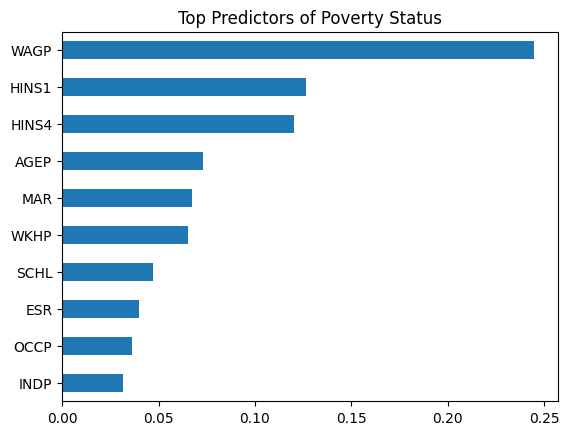

In [ ]:
feature_importance.head(10).plot(kind="barh")
plt.title("Top Predictors of Poverty Status")
plt.gca().invert_yaxis()
plt.show()

Random Forest Model Analysis:
- Wage Income (WAGP) is the strongest predictor of poverty which conferms that poverty risk in California is primarily income driven as opposed to being solely based on demographics.
- Health Insurance status is also a strong predictor and we can see that households that depend on Medicaid or do not have access to employer based insurance are more vulnerable to poverty.
- Age is another factor that contributes heavily to the risk of poverty with younger workers and elderly individuals facing higher risk of poverty.
- Single individuals are at a higher risk of poverty compared to married households likely due to income pooling effects.
- Underemployment (Low WKHP) contributes to poverty risk even when employed.
- Surprisingly, the feature importance of education is lower but still important suggesting that education primarily reduces poverty through its effects on earnings and employment stability rather than having a direct effect.

Overall, the results suggest that employment quality and access to benefits play a larger part in predicting poverty status.

### Model 3: XGBoost

In [ ]:
!pip -q install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [ ]:
# Check class imbalance
y_train.value_counts()

,count
poverty_status,
0,16322
1,2290


In [ ]:
# Calculate scale_pos_weight for class imbalance
negative_class = sum(y_train == 0)
positive_class = sum(y_train == 1)

scale_pos_weight = negative_class / positive_class
scale_pos_weight

7.127510917030568

In [ ]:
# Build XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Make predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate model
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7692307692307693
XGBoost AUC: 0.8602921147935848

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.76      0.85      4082
           1       0.33      0.83      0.47       572

    accuracy                           0.77      4654
   macro avg       0.65      0.79      0.66      4654
weighted avg       0.89      0.77      0.81      4654


Confusion Matrix:

[[3108  974]
 [ 100  472]]


In [ ]:
# Feature importance
xgb_feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

xgb_feature_importance.head(10)

,0
HINS1,0.186080
WAGP,0.170902
HINS4,0.157214
HICOV,0.080134
MAR,0.068116
ESR,0.043339
AGEP,0.028277
WKHP,0.025951
CIT,0.021643
HINS2,0.019720


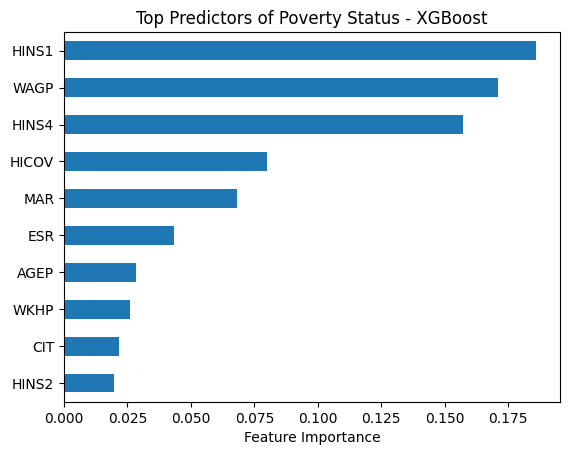

In [ ]:
# Plot top predictors
xgb_feature_importance.head(10).plot(kind="barh")
plt.title("Top Predictors of Poverty Status - XGBoost")
plt.xlabel("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Save the trained XGBoost model
import joblib

joblib.dump(xgb_model, "xgb_poverty_model.pkl")
print("XGBoost model saved successfully.")

XGBoost model saved successfully.


### Results Analysis

The XGBoost model achieved strong overall performance, with an **accuracy of 0.769** and an **AUC of 0.860**, indicating a high ability to distinguish between poverty and non-poverty cases. The relatively high AUC suggests that the model performs well across different classification thresholds, not just at a fixed cutoff.

A closer look at the classification report highlights an important tradeoff between precision and recall. For the majority class (non-poverty, class 0), the model performs exceptionally well, with **precision of 0.97** and **recall of 0.76**, meaning most non-poverty predictions are correct while still capturing a large portion of actual cases.

For the minority class (poverty, class 1), the model achieves a **high recall of 0.83**, indicating that it successfully identifies most individuals in poverty. This is a key strength of the model, as minimizing false negatives is especially important in this context. However, the **precision is lower at 0.33**, meaning that a significant number of non-poverty cases are incorrectly classified as poverty (false positives).

The confusion matrix provides further insight:
- True Negatives: 3108  
- False Positives: 974  
- False Negatives: 100  
- True Positives: 472  

The relatively low number of false negatives (100) compared to true positives (472) confirms that the model is effective at capturing poverty cases. However, the higher number of false positives (974) reflects the tradeoff made to achieve this high recall. This indicates that the model is somewhat biased toward predicting the positive class, which is often intentional when dealing with imbalanced datasets.

The difference between **macro average (F1 = 0.66)** and **weighted average (F1 = 0.81)** further highlights class imbalance. The weighted average is higher because it is influenced more by the majority class, while the macro average shows that performance on the minority class is weaker, primarily due to lower precision.

Feature importance analysis shows that the most influential variables include:
- **HINS1, HINS4, HICOV** → health insurance coverage  
- **WAGP** → wage/income  
- **ESR, WKHP** → employment status and work hours  
- **MAR, AGEP** → demographic characteristics  

These features are consistent with known socioeconomic determinants of poverty, suggesting that the model is learning meaningful and interpretable patterns rather than noise.

Compared to Random Forest, XGBoost benefits from its boosting mechanism, which allows it to iteratively correct errors and focus on harder-to-classify observations. This results in improved AUC and better recall for the minority class, making it more effective for this prediction task.

Overall, the XGBoost model provides a strong and well-balanced approach to poverty prediction. While there is a tradeoff in precision, the model’s ability to correctly identify the majority of poverty cases makes it particularly valuable in scenarios where missing a positive case is more costly than a false alarm.